# Quick QA/QC — 2016 Sentinel-2 Monthly Median Reference Raster

Expected source:

```text
gs://bop-nca-data-space-s2-c1-staging/
monthly_medians/harmonic_feature_space_2016_2017/2016/
S2SR_MonthlyMedians_2016...
```

Expected structure: **192 bands/year** = 15 analysis variables × 12 months + 12 monthly `nObs` bands.

This notebook performs a fast diagnostic of:
- raster/shard consistency;
- 192-band schema;
- monthly valid coverage;
- monthly `nObs`;
- basic value distributions;
- monthly index seasonality.

All TIFFs and QA outputs use an **absolute scratch path** under `C:\NCA_DATA\scratch\`. No TIFF is written to or read from a relative path.


In [1]:
# Optional one-time install
# %pip install -q numpy pandas matplotlib rasterio google-cloud-storage

from pathlib import Path
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


## 1. Configuration

In [2]:
YEAR = 2016

GCS_BUCKET = "bop-nca-data-space-s2-c1-staging"
GCS_PREFIX = (
    "monthly_medians/"
    "harmonic_feature_space_2016_2017/"
    "2016/"
    "S2SR_MonthlyMedians_2016"
)

SCRATCH_ROOT = Path(
    r"C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC"
)

if not SCRATCH_ROOT.is_absolute():
    raise ValueError("SCRATCH_ROOT must be an explicit absolute path.")

TIFF_DIR = SCRATCH_ROOT / "tif_shards"
QA_DIR = SCRATCH_ROOT / "QAQC"
TIFF_DIR.mkdir(parents=True, exist_ok=True)
QA_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES_PER_SHARD = 20_000

ANALYSIS_BANDS = [
    "B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12",
    "NDVI","NDMI","NDRE","BSI","NBR2",
]
MONTHS = list(range(1, 13))

EXPECTED_BANDS = []
for month in MONTHS:
    mm = f"{month:02d}"
    EXPECTED_BANDS.extend([f"{b}_M{mm}" for b in ANALYSIS_BANDS])
    EXPECTED_BANDS.append(f"nObs_M{mm}")

EXPECTED_COUNT = len(EXPECTED_BANDS)

print("Scratch root:", SCRATCH_ROOT)
print("Expected bands:", EXPECTED_COUNT)


Scratch root: C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC
Expected bands: 192


## 2. Download/discover the 2016 shards

In [3]:
def local_tifs():
    paths = sorted(p for p in TIFF_DIR.glob("*.tif") if p.is_file())
    for p in paths:
        if not p.is_absolute():
            raise ValueError(f"Relative TIFF path detected: {p}")
    return paths

tifs = local_tifs()

if not tifs:
    from google.cloud import storage
    client = storage.Client()

    blobs = [
        b for b in client.list_blobs(GCS_BUCKET, prefix=GCS_PREFIX)
        if b.name.lower().endswith(".tif")
    ]

    if not blobs:
        raise FileNotFoundError(
            f"No TIFFs found under gs://{GCS_BUCKET}/{GCS_PREFIX}"
        )

    print(f"Downloading {len(blobs)} shard(s) to {TIFF_DIR}")

    for blob in blobs:
        out = TIFF_DIR / Path(blob.name).name
        if not out.is_absolute():
            raise ValueError("Refusing to write TIFF to a relative path.")
        if not out.exists():
            blob.download_to_filename(str(out))

    tifs = local_tifs()

print("Local TIFF shards:", len(tifs))
for p in tifs:
    print(" ", p)


Local TIFF shards: 20
  C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC\tif_shards\S2SR_MonthlyMedians_20160000000000-0000000000.tif
  C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC\tif_shards\S2SR_MonthlyMedians_20160000000000-0000002560.tif
  C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC\tif_shards\S2SR_MonthlyMedians_20160000000000-0000005120.tif
  C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC\tif_shards\S2SR_MonthlyMedians_20160000000000-0000007680.tif
  C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC\tif_shards\S2SR_MonthlyMedians_20160000000000-0000010240.tif
  C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC\tif_shards\S2SR_MonthlyMedians_20160000002560-0000000000.tif
  C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC\tif_shards\S2SR_MonthlyMedians_20160000002560-0000002560.tif
  C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC\tif_shards\S2SR_MonthlyMedians_20160000002560-0000005120.tif
  C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC\tif_shards\S2SR_MonthlyMedians_

## 3. Raster inventory + schema

In [4]:
def raster_info(path):
    path = Path(path)
    if not path.is_absolute():
        raise ValueError(f"Relative raster path: {path}")

    with rasterio.open(path) as src:
        return {
            "file": path.name,
            "path": str(path),
            "width": src.width,
            "height": src.height,
            "count": src.count,
            "dtype": ",".join(sorted(set(src.dtypes))),
            "crs": str(src.crs),
            "res_x": abs(src.transform.a),
            "res_y": abs(src.transform.e),
            "nodata": src.nodata,
            "descriptions": list(src.descriptions),
        }

inventory_raw = [raster_info(p) for p in tifs]

inventory = pd.DataFrame([
    {k:v for k,v in row.items() if k != "descriptions"}
    for row in inventory_raw
])

display(inventory)
inventory.to_csv(QA_DIR / "raster_inventory.csv", index=False)

first_desc = inventory_raw[0]["descriptions"]

if all(x is not None for x in first_desc):
    band_names = list(first_desc)
else:
    band_names = EXPECTED_BANDS.copy()
    print("WARNING: band descriptions missing; assuming expected export order.")

for row in inventory_raw[1:]:
    desc = list(row["descriptions"])
    if all(x is not None for x in desc) and desc != list(first_desc):
        raise AssertionError(f"Band descriptions differ in {row['file']}")

missing = [b for b in EXPECTED_BANDS if b not in band_names]
extra = [b for b in band_names if b not in EXPECTED_BANDS]

schema = pd.DataFrame({
    "check": [
        "observed_band_count",
        "expected_band_count",
        "missing_expected_bands",
        "unexpected_bands",
        "single_crs",
        "single_resolution",
        "single_nodata",
    ],
    "value": [
        len(band_names),
        EXPECTED_COUNT,
        len(missing),
        len(extra),
        inventory["crs"].nunique() == 1,
        len(inventory[["res_x","res_y"]].drop_duplicates()) == 1,
        inventory["nodata"].nunique() == 1,
    ],
})

display(schema)
print("Missing:", missing)
print("Extra:", extra)

schema.to_csv(QA_DIR / "schema_QA.csv", index=False)


,file,path,width,height,count,dtype,crs,res_x,res_y,nodata
0,S2SR_MonthlyMedians_20160000000000-0000000000.tif,C:\NCA_DATA\scratch\S2_monthly_medians_2016_QA...,2560,2560,192,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0
1,S2SR_MonthlyMedians_20160000000000-0000002560.tif,C:\NCA_DATA\scratch\S2_monthly_medians_2016_QA...,2560,2560,192,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0
2,S2SR_MonthlyMedians_20160000000000-0000005120.tif,C:\NCA_DATA\scratch\S2_monthly_medians_2016_QA...,2560,2560,192,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0
3,S2SR_MonthlyMedians_20160000000000-0000007680.tif,C:\NCA_DATA\scratch\S2_monthly_medians_2016_QA...,2560,2560,192,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0
4,S2SR_MonthlyMedians_20160000000000-0000010240.tif,C:\NCA_DATA\scratch\S2_monthly_medians_2016_QA...,195,2560,192,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0
5,S2SR_MonthlyMedians_20160000002560-0000000000.tif,C:\NCA_DATA\scratch\S2_monthly_medians_2016_QA...,2560,2560,192,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0
6,S2SR_MonthlyMedians_20160000002560-0000002560.tif,C:\NCA_DATA\scratch\S2_monthly_medians_2016_QA...,2560,2560,192,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0
7,S2SR_MonthlyMedians_20160000002560-0000005120.tif,C:\NCA_DATA\scratch\S2_monthly_medians_2016_QA...,2560,2560,192,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0
8,S2SR_MonthlyMedians_20160000002560-0000007680.tif,C:\NCA_DATA\scratch\S2_monthly_medians_2016_QA...,2560,2560,192,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0
9,S2SR_MonthlyMedians_20160000002560-0000010240.tif,C:\NCA_DATA\scratch\S2_monthly_medians_2016_QA...,195,2560,192,float32,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",10.0,10.0,-32768.0


,check,value
0,observed_band_count,192
1,expected_band_count,192
2,missing_expected_bands,0
3,unexpected_bands,0
4,single_crs,True
5,single_resolution,True
6,single_nodata,True


Missing: []
Extra: []


## 4. Spatially distributed sample

In [5]:
def sample_shard(path, target_n=SAMPLES_PER_SHARD):
    path = Path(path)
    if not path.is_absolute():
        raise ValueError(f"Relative raster path: {path}")

    with rasterio.open(path) as src:
        aspect = src.width / src.height
        out_h = max(1, int(math.sqrt(target_n / aspect)))
        out_w = max(1, int(out_h * aspect))

        arr = src.read(
            out_shape=(src.count, out_h, out_w),
            resampling=Resampling.nearest,
        ).astype("float64")

        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

        arr[~np.isfinite(arr)] = np.nan

        df = pd.DataFrame(
            arr.reshape(src.count, -1).T,
            columns=band_names,
        )
        df["source_shard"] = path.name
        return df

parts = []
for path in tifs:
    part = sample_shard(path)
    parts.append(part)
    print(path.name, "->", f"{len(part):,}", "sample locations")

sample = pd.concat(parts, ignore_index=True)
print("Total sampled locations:", f"{len(sample):,}")


S2SR_MonthlyMedians_20160000000000-0000000000.tif -> 19,881 sample locations
S2SR_MonthlyMedians_20160000000000-0000002560.tif -> 19,881 sample locations
S2SR_MonthlyMedians_20160000000000-0000005120.tif -> 19,881 sample locations
S2SR_MonthlyMedians_20160000000000-0000007680.tif -> 19,881 sample locations
S2SR_MonthlyMedians_20160000000000-0000010240.tif -> 19,968 sample locations
S2SR_MonthlyMedians_20160000002560-0000000000.tif -> 19,881 sample locations
S2SR_MonthlyMedians_20160000002560-0000002560.tif -> 19,881 sample locations
S2SR_MonthlyMedians_20160000002560-0000005120.tif -> 19,881 sample locations
S2SR_MonthlyMedians_20160000002560-0000007680.tif -> 19,881 sample locations
S2SR_MonthlyMedians_20160000002560-0000010240.tif -> 19,968 sample locations
S2SR_MonthlyMedians_20160000005120-0000000000.tif -> 19,881 sample locations
S2SR_MonthlyMedians_20160000005120-0000002560.tif -> 19,881 sample locations
S2SR_MonthlyMedians_20160000005120-0000005120.tif -> 19,881 sample locations

## 5. Monthly observation support

,month,valid_fraction,pct_nObs_gt_0,pct_nObs_ge_2,pct_nObs_ge_3,p05,median,mean,p95,max
0,1,0.001183,0.118282,0.054108,0.000252,1.0,1.0,1.459574,2.0,3.0
1,2,0.000305,0.030451,0.000000,0.000000,1.0,1.0,1.000000,1.0,1.0
2,3,0.001374,0.137409,0.004782,0.000000,1.0,1.0,1.034799,1.0,2.0
3,4,0.001359,0.135899,0.105196,0.048320,1.0,2.0,2.155556,3.0,4.0
4,5,0.001216,0.121554,0.045551,0.002517,1.0,1.0,1.395445,2.0,3.0
5,6,0.001331,0.133131,0.123819,0.064930,1.0,2.0,2.444234,3.0,4.0
6,7,0.001392,0.139171,0.133634,0.104441,2.0,6.0,4.663653,7.0,7.0
7,8,0.001369,0.136906,0.130866,0.084056,2.0,3.0,2.915441,4.0,4.0
8,9,0.001394,0.139422,0.124322,0.095129,1.0,4.0,3.270758,5.0,6.0
9,10,0.001097,0.109726,0.089089,0.012080,1.0,2.0,1.922018,3.0,3.0


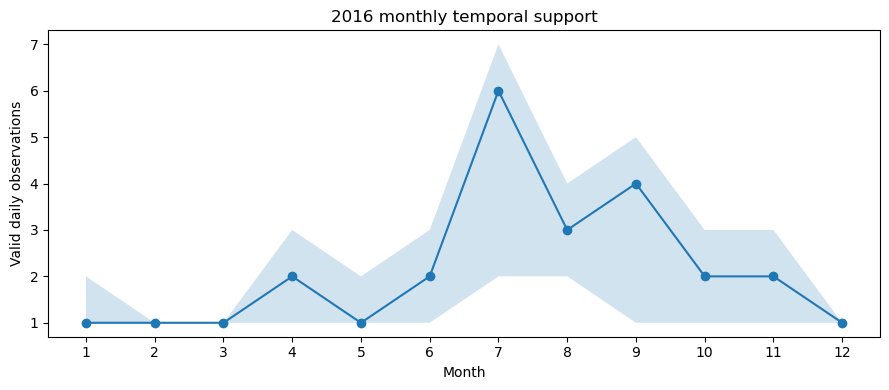

In [6]:
nobs_rows = []

for month in MONTHS:
    band = f"nObs_M{month:02d}"
    if band not in sample:
        continue

    x = sample[band]
    valid = x.dropna()

    nobs_rows.append({
        "month": month,
        "valid_fraction": valid.size / len(x),
        "pct_nObs_gt_0": 100*np.mean(x.fillna(0) > 0),
        "pct_nObs_ge_2": 100*np.mean(x.fillna(0) >= 2),
        "pct_nObs_ge_3": 100*np.mean(x.fillna(0) >= 3),
        "p05": valid.quantile(0.05) if len(valid) else np.nan,
        "median": valid.median() if len(valid) else np.nan,
        "mean": valid.mean() if len(valid) else np.nan,
        "p95": valid.quantile(0.95) if len(valid) else np.nan,
        "max": valid.max() if len(valid) else np.nan,
    })

nobs_summary = pd.DataFrame(nobs_rows)
display(nobs_summary)

nobs_summary.to_csv(
    QA_DIR / "monthly_nObs_summary.csv",
    index=False
)

plt.figure(figsize=(9,4))
plt.plot(nobs_summary["month"], nobs_summary["median"], marker="o")
plt.fill_between(
    nobs_summary["month"],
    nobs_summary["p05"],
    nobs_summary["p95"],
    alpha=0.2,
)
plt.xticks(MONTHS)
plt.xlabel("Month")
plt.ylabel("Valid daily observations")
plt.title("2016 monthly temporal support")
plt.tight_layout()
plt.show()


## 6. Monthly valid coverage

In [7]:
coverage_rows = []

for month in MONTHS:
    mm = f"{month:02d}"

    for variable in ANALYSIS_BANDS:
        band = f"{variable}_M{mm}"
        if band not in sample:
            continue

        coverage_rows.append({
            "month": month,
            "variable": variable,
            "valid_fraction": sample[band].notna().mean(),
        })

coverage = pd.DataFrame(coverage_rows)

coverage_pivot = coverage.pivot(
    index="month",
    columns="variable",
    values="valid_fraction",
)

display(coverage_pivot)

coverage.to_csv(
    QA_DIR / "monthly_band_valid_fraction.csv",
    index=False
)


variable,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,BSI,NBR2,NDMI,NDRE,NDVI
month,,,,,,,,,,,,,,,
1,0.001183,0.001183,0.001183,0.001183,0.001183,0.001183,0.001183,0.001183,0.001183,0.001183,0.001183,0.001183,0.001183,0.001183,0.001183
2,0.000305,0.000305,0.000305,0.000305,0.000305,0.000305,0.000305,0.000305,0.000305,0.000305,0.000305,0.000305,0.000305,0.000305,0.000305
3,0.001374,0.001374,0.001374,0.001374,0.001374,0.001374,0.001374,0.001374,0.001374,0.001374,0.001374,0.001374,0.001374,0.001374,0.001374
4,0.001359,0.001359,0.001359,0.001359,0.001359,0.001359,0.001359,0.001359,0.001359,0.001359,0.001359,0.001359,0.001359,0.001359,0.001359
5,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216
6,0.001331,0.001331,0.001331,0.001331,0.001331,0.001331,0.001331,0.001331,0.001331,0.001331,0.001331,0.001331,0.001331,0.001331,0.001331
7,0.001392,0.001392,0.001392,0.001392,0.001392,0.001392,0.001392,0.001392,0.001392,0.001392,0.001392,0.001392,0.001392,0.001392,0.001392
8,0.001369,0.001369,0.001369,0.001369,0.001369,0.001369,0.001369,0.001369,0.001369,0.001369,0.001369,0.001369,0.001369,0.001369,0.001369
9,0.001394,0.001394,0.001394,0.001394,0.001394,0.001394,0.001394,0.001394,0.001394,0.001394,0.001394,0.001394,0.001394,0.001394,0.001394


## 7. Band-value summary

In [8]:
summary_rows = []

for band in band_names:
    if band.startswith("nObs_"):
        continue

    x = sample[band].dropna()
    if len(x) == 0:
        continue

    summary_rows.append({
        "band": band,
        "n_valid": len(x),
        "valid_fraction": len(x)/len(sample),
        "min": x.min(),
        "p01": x.quantile(0.01),
        "p05": x.quantile(0.05),
        "median": x.median(),
        "mean": x.mean(),
        "p95": x.quantile(0.95),
        "p99": x.quantile(0.99),
        "max": x.max(),
    })

band_summary = pd.DataFrame(summary_rows)
display(band_summary)

band_summary.to_csv(
    QA_DIR / "band_distribution_summary.csv",
    index=False
)


,band,n_valid,valid_fraction,min,p01,p05,median,mean,p95,p99,max
0,B2_M01,470,0.001183,0.116800,0.133149,0.140635,0.161075,0.164413,0.199910,0.217528,0.247000
1,B3_M01,470,0.001183,0.137800,0.143818,0.154245,0.180275,0.186025,0.229665,0.252727,0.270000
2,B4_M01,470,0.001183,0.137400,0.155754,0.164290,0.200500,0.207184,0.268320,0.287545,0.314800
3,B5_M01,470,0.001183,0.168250,0.178225,0.196729,0.235200,0.238394,0.296195,0.316829,0.338800
4,B6_M01,470,0.001183,0.182125,0.192274,0.215610,0.262925,0.269939,0.344365,0.402994,0.478900
...,...,...,...,...,...,...,...,...,...,...,...
175,NDVI_M12,495,0.001246,0.043224,0.052344,0.080313,0.193017,0.230329,0.498026,0.561002,0.597111
176,NDMI_M12,495,0.001246,-0.177206,-0.159007,-0.113931,0.008936,0.029460,0.203361,0.280421,0.318438
177,NDRE_M12,495,0.001246,-0.041321,-0.020609,0.009599,0.063017,0.063499,0.115590,0.154392,0.181282
178,BSI_M12,495,0.001246,-0.210718,-0.189188,-0.125056,0.048937,0.024270,0.119996,0.142377,0.153930


## 8. Monthly index seasonality

,variable,month,median,p25,p75
0,NDVI,1,0.157566,0.120020,0.206058
1,NDVI,2,0.142857,0.111811,0.172657
2,NDVI,3,0.279159,0.166263,0.383709
3,NDVI,4,0.266739,0.167058,0.416250
4,NDVI,5,0.233110,0.146486,0.448446
5,NDVI,6,0.165138,0.107304,0.383808
6,NDVI,7,0.167893,0.104467,0.320283
7,NDVI,8,0.160401,0.100307,0.378943
8,NDVI,9,0.156188,0.103732,0.361393
9,NDVI,10,0.134607,0.097540,0.258352


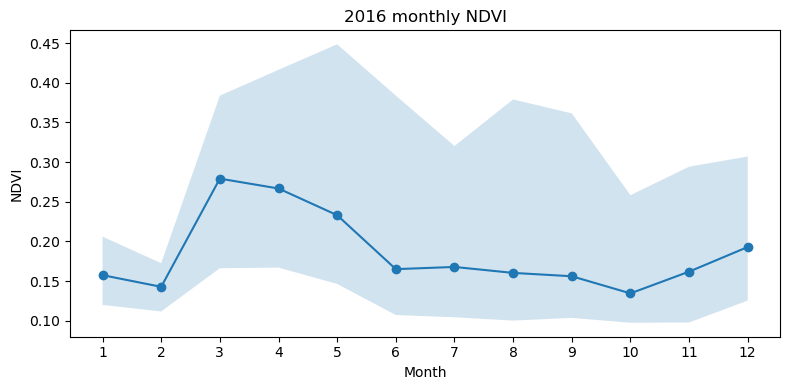

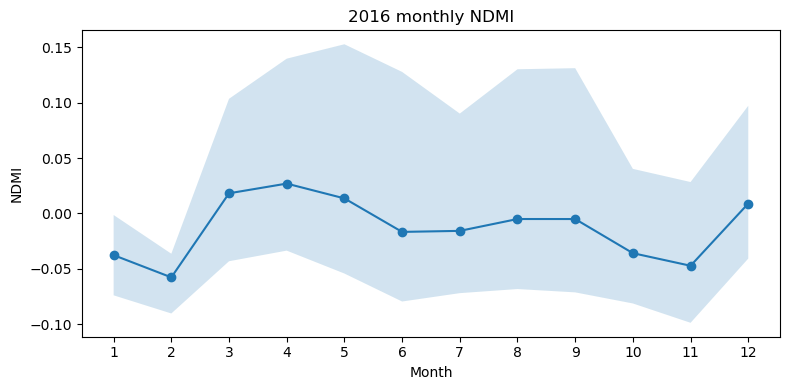

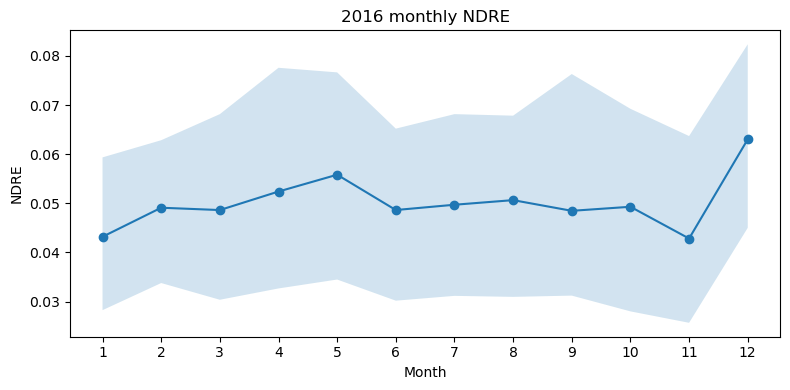

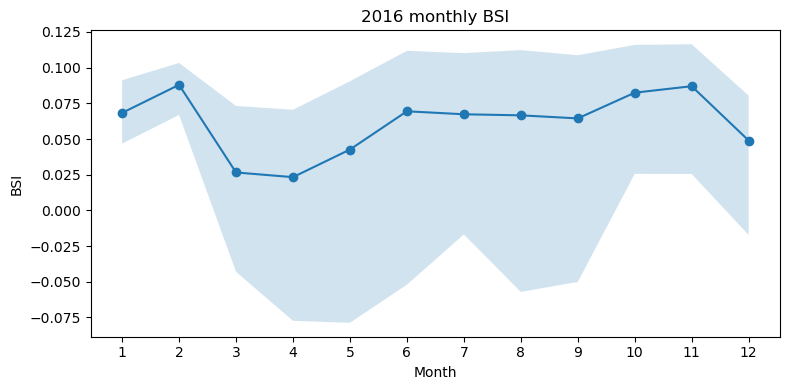

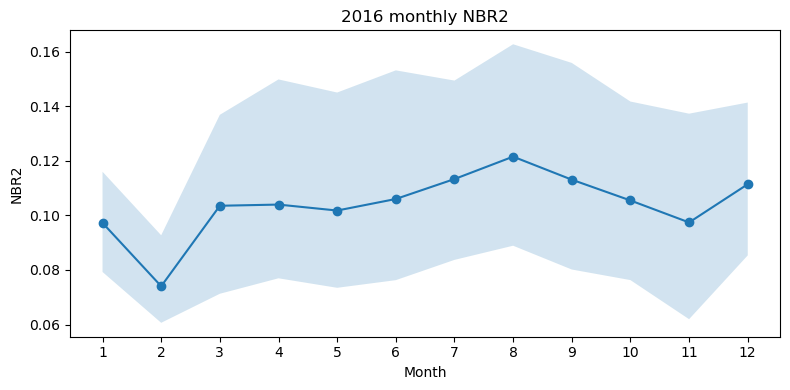

In [9]:
INDEX_BANDS = ["NDVI","NDMI","NDRE","BSI","NBR2"]

index_rows = []

for variable in INDEX_BANDS:
    for month in MONTHS:
        band = f"{variable}_M{month:02d}"
        if band not in sample:
            continue

        x = sample[band].dropna()
        if not len(x):
            continue

        index_rows.append({
            "variable": variable,
            "month": month,
            "median": x.median(),
            "p25": x.quantile(0.25),
            "p75": x.quantile(0.75),
        })

index_seasonality = pd.DataFrame(index_rows)
display(index_seasonality)

index_seasonality.to_csv(
    QA_DIR / "monthly_index_seasonality.csv",
    index=False
)

for variable in INDEX_BANDS:
    d = index_seasonality[
        index_seasonality["variable"] == variable
    ]

    plt.figure(figsize=(8,4))
    plt.plot(d["month"], d["median"], marker="o")
    plt.fill_between(
        d["month"],
        d["p25"],
        d["p75"],
        alpha=0.2,
    )
    plt.xticks(MONTHS)
    plt.xlabel("Month")
    plt.ylabel(variable)
    plt.title(f"2016 monthly {variable}")
    plt.tight_layout()
    plt.show()


## 9. Broad anomaly flags

In [10]:
flags = []

# Normalized indices.
for variable in ["NDVI","NDMI","NDRE","BSI","NBR2"]:
    for month in MONTHS:
        band = f"{variable}_M{month:02d}"
        if band not in sample:
            continue

        x = sample[band].dropna()
        if not len(x):
            continue

        flags.append({
            "band": band,
            "check": "outside_-1_1",
            "fraction": np.mean(
                (x < -1.0001) | (x > 1.0001)
            ),
        })

# Very broad reflectance sanity range.
for variable in ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12"]:
    for month in MONTHS:
        band = f"{variable}_M{month:02d}"
        if band not in sample:
            continue

        x = sample[band].dropna()
        if not len(x):
            continue

        flags.append({
            "band": band,
            "check": "reflectance_outside_-0.1_1.5",
            "fraction": np.mean(
                (x < -0.1) | (x > 1.5)
            ),
        })

flag_table = pd.DataFrame(flags)

display(
    flag_table[
        flag_table["fraction"] > 0
    ].sort_values(
        "fraction",
        ascending=False
    )
)

flag_table.to_csv(
    QA_DIR / "anomaly_flags.csv",
    index=False
)


,band,check,fraction


## 10. Compact QA summary

In [11]:
qa_summary = pd.DataFrame({
    "check": [
        "scratch_root_absolute",
        "n_shards",
        "observed_band_count",
        "expected_band_count",
        "schema_complete",
        "single_crs",
        "single_resolution",
        "single_nodata",
        "sample_locations",
        "months_with_nObs",
    ],
    "value": [
        SCRATCH_ROOT.is_absolute(),
        len(tifs),
        len(band_names),
        EXPECTED_COUNT,
        len(missing) == 0 and len(extra) == 0 and len(band_names) == EXPECTED_COUNT,
        inventory["crs"].nunique() == 1,
        len(inventory[["res_x","res_y"]].drop_duplicates()) == 1,
        inventory["nodata"].nunique() == 1,
        len(sample),
        len(nobs_summary),
    ],
})

display(qa_summary)

qa_summary.to_csv(
    QA_DIR / "QAQC_summary.csv",
    index=False
)

print("QA outputs written to:")
print(QA_DIR)


,check,value
0,scratch_root_absolute,True
1,n_shards,20
2,observed_band_count,192
3,expected_band_count,192
4,schema_complete,True
5,single_crs,True
6,single_resolution,True
7,single_nodata,True
8,sample_locations,397354
9,months_with_nObs,12


QA outputs written to:
C:\NCA_DATA\scratch\S2_monthly_medians_2016_QAQC\QAQC


## First-pass interpretation

For the quick diagnostic, inspect:

1. `schema_QA.csv` — confirm all 192 bands are present.
2. `monthly_nObs_summary.csv` — identify months with weak temporal support.
3. `monthly_band_valid_fraction.csv` — identify unusual missingness.
4. The five monthly index curves — confirm plausible seasonal structure.
5. `anomaly_flags.csv` — catch obvious scaling or index failures.

If these are clean, the 2016 median raster is ready for the targeted fixed-pixel sampling workflow.

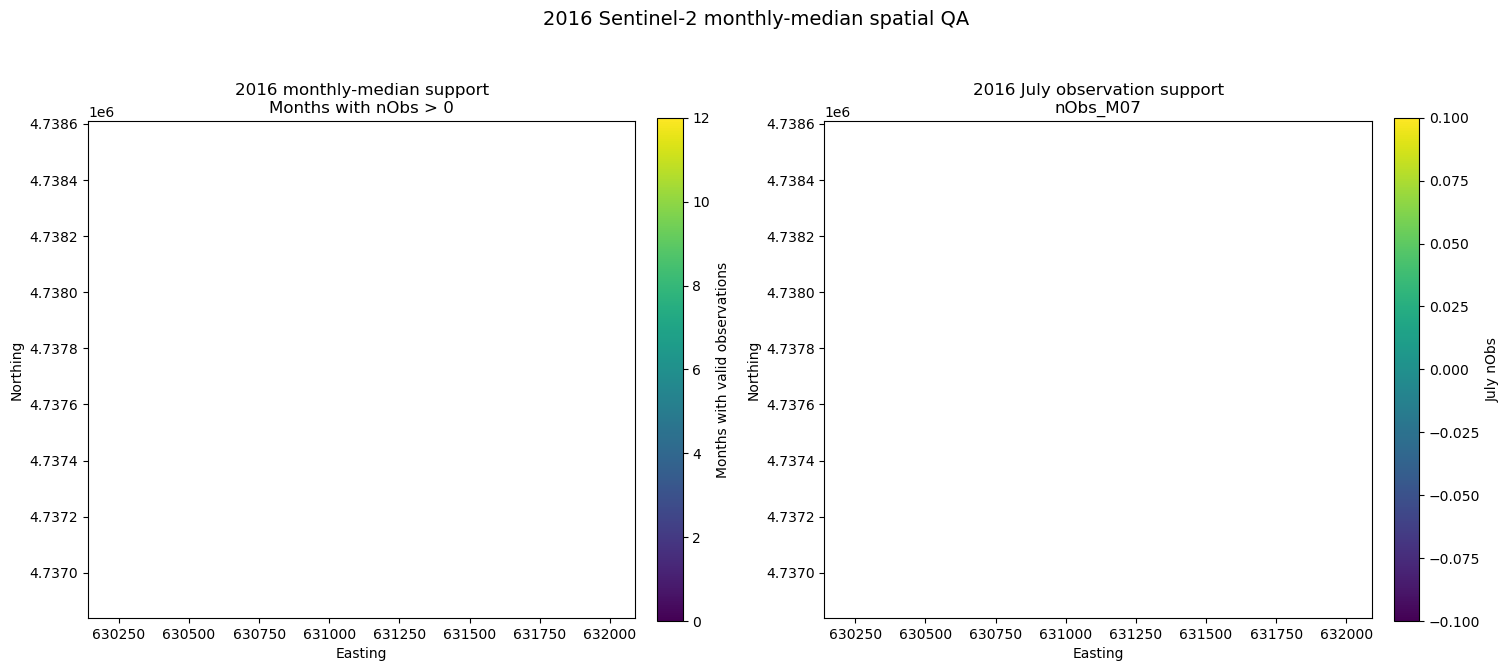

In [12]:
# =============================================================================
# 11. INLINE SPATIAL SUPPORT MAP — NO EXPORT
# =============================================================================

from rasterio.plot import plotting_extent

NOBS_BANDS = [
    f"nObs_M{month:02d}"
    for month in MONTHS
]

missing_nobs = [
    band
    for band in NOBS_BANDS
    if band not in band_names
]

if missing_nobs:
    raise KeyError(
        "Missing monthly nObs bands required for the map: "
        + ", ".join(missing_nobs)
    )

nobs_indexes = [
    band_names.index(band) + 1
    for band in NOBS_BANDS
]

july_band = "nObs_M07"
july_index = band_names.index(july_band) + 1

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7),
    constrained_layout=True,
)

valid_month_im = None
july_im = None

for path in tifs:
    with rasterio.open(path) as src:

        # Downsample for display only. The spatial extent remains the full shard
        # extent, so adjacent shards still plot in their correct map positions.
        max_preview_dim = 900
        scale = min(
            1.0,
            max_preview_dim / max(src.width, src.height),
        )

        out_w = max(1, int(round(src.width * scale)))
        out_h = max(1, int(round(src.height * scale)))

        monthly_nobs = src.read(
            nobs_indexes,
            out_shape=(len(nobs_indexes), out_h, out_w),
            masked=True,
            resampling=Resampling.nearest,
        )

        valid_months = np.ma.sum(
            monthly_nobs > 0,
            axis=0,
        )

        all_months_masked = np.ma.getmaskarray(
            monthly_nobs
        ).all(axis=0)

        valid_months = np.ma.masked_where(
            all_months_masked,
            valid_months,
        )

        july_nobs = src.read(
            july_index,
            out_shape=(out_h, out_w),
            masked=True,
            resampling=Resampling.nearest,
        )

        extent = plotting_extent(src)

        valid_month_im = axes[0].imshow(
            valid_months,
            extent=extent,
            origin="upper",
            vmin=0,
            vmax=12,
            interpolation="nearest",
        )

        july_im = axes[1].imshow(
            july_nobs,
            extent=extent,
            origin="upper",
            vmin=0,
            interpolation="nearest",
        )

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")

axes[0].set_title(
    f"{YEAR} monthly-median support\n"
    "Months with nObs > 0"
)

axes[1].set_title(
    f"{YEAR} July observation support\n"
    "nObs_M07"
)

if valid_month_im is not None:
    cbar0 = fig.colorbar(
        valid_month_im,
        ax=axes[0],
        fraction=0.046,
        pad=0.04,
    )
    cbar0.set_label("Months with valid observations")

if july_im is not None:
    cbar1 = fig.colorbar(
        july_im,
        ax=axes[1],
        fraction=0.046,
        pad=0.04,
    )
    cbar1.set_label("July nObs")

fig.suptitle(
    "2016 Sentinel-2 monthly-median spatial QA",
    fontsize=14,
)

plt.show()
